# 问题三：影响因素分析

## 问题描述
分析专业舞伴和明星特征对比赛结果的影响。

## 核心任务
1. 分析专业舞伴对选手成绩的影响
2. 分析明星行业、年龄等特征的影响
3. 量化各因素的重要性

## 建模方法
- **ANOVA**：检验组间差异显著性
- **回归分析**：量化因素影响
- **随机森林**：特征重要性排序

In [1]:
# ===== O奖级全局设置 =====
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import cross_val_score
import warnings
import os
warnings.filterwarnings('ignore')

os.makedirs('figures', exist_ok=True)

plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'axes.linewidth': 1.2,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'legend.frameon': False,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 统一配色方案（学术风）
COLORS = {
    # 主色调
    'primary': '#367DB0',           # 深蓝 - 主色
    'secondary': '#3D9F3C',         # 深绿 - 副色
    
    # 浅色变体
    'light_blue': '#9DC7DD',        # 浅蓝
    'light_green': '#9ED17B',       # 浅绿
    
    # 灰色调
    'gray_blue': '#5385BD',         # 灰蓝
    'gray_green': '#519D78',        # 灰绿
    
    # 强调色
    'orange': '#FF7F0E',            # 橙色（对比/警示）
    'purple': '#9467BD',            # 紫色（第三组）
    'red': '#D62728',               # 红色（负值/警示）
    
    # 中性色
    'neutral': '#7D8491',           # 灰色
    'light_gray': '#D3D3D3',        # 浅灰
    
    # 填充色
    'fill_blue': '#DAE8FC',         # 浅蓝填充
    'fill_green': '#E8F5E9',        # 浅绿填充
    'fill_orange': '#FFF3E0',       # 浅橙填充
    
    # 兼容旧名称
    'rank_method': '#367DB0',
    'pct_method': '#3D9F3C',
    'controversial': '#FF7F0E',
    'normal': '#7D8491',
    'early_season': '#5385BD',
    'late_season': '#FF7F0E',
    'dwvs': '#3D9F3C',
    'light': '#DAE8FC',
    'light_red': '#FFF3E0',
}

# 折线图专用配色
LINE_COLORS = {
    'line1': '#1F77B4',             # 深蓝
    'line2': '#FF7F0E',             # 橙色
    'line3': '#9467BD',             # 紫色
    'line4': '#2CA02C',             # 绿色
}

FIG_DOUBLE = (10, 4)
FIG_SINGLE = (5, 4)

print('环境配置完成')

环境配置完成


## 第一步：加载数据

In [2]:
# 加载数据
df_summary = pd.read_csv('../数据预处理/data_season_summary.csv')
df_long = pd.read_csv('../数据预处理/data_long_format.csv')

print(f'季汇总数据: {df_summary.shape}')
print(f'长格式数据: {df_long.shape}')

季汇总数据: (421, 29)
长格式数据: (2777, 28)


In [3]:
# 数据准备
df_analysis = df_summary.copy()

# 处理年龄
df_analysis['age'] = pd.to_numeric(df_analysis['celebrity_age'], errors='coerce')
df_analysis = df_analysis[df_analysis['age'].notna()]

# 创建分类变量
df_analysis['is_winner'] = (df_analysis['placement'] == 1).astype(int)
df_analysis['is_top3'] = (df_analysis['placement'] <= 3).astype(int)

# 行业分组
top_industries = df_analysis['celebrity_industry'].value_counts().head(6).index.tolist()
df_analysis['industry_grouped'] = df_analysis['celebrity_industry'].apply(
    lambda x: x if x in top_industries else 'Other'
)

# 年龄分组
df_analysis['age_group'] = pd.cut(df_analysis['age'], bins=[0, 25, 35, 45, 100], labels=['<25', '25-35', '35-45', '45+'])

print(f'分析样本: {len(df_analysis)} 条')

分析样本: 421 条


## 第二步：专业舞伴影响分析

In [4]:
# 按专业舞者分组统计
pro_stats = df_analysis.groupby('ballroom_partner').agg({
    'placement': ['mean', 'std', 'count'],
    'avg_judge_score': 'mean',
    'is_winner': 'sum',
    'is_top3': 'sum'
}).round(2)
pro_stats.columns = ['avg_placement', 'std_placement', 'partnerships', 'avg_score', 'wins', 'top3']
pro_stats = pro_stats[pro_stats['partnerships'] >= 3].sort_values('avg_placement')

print('='*60)
print('【专业舞者统计 (>=3次合作)】')
print('='*60)
print(pro_stats.head(10).to_string())

【专业舞者统计 (>=3次合作)】
                       avg_placement  std_placement  partnerships  avg_score  wins  top3
ballroom_partner                                                                        
Derek Hough                     2.94           1.82            17       8.88     6     9
Julianne Hough                  4.20           3.42             5       7.85     2     2
Daniella Karagach               4.60           4.04             5       7.85     1     3
Mark Ballas                     5.19           3.54            21       8.29     3    10
Valentin Chmerkovskiy           5.26           3.57            19       8.37     3     9
Lindsay Arnold                  5.40           3.41            10       7.58     1     4
Witney Carson                   5.50           3.39            14       7.90     1     5
Cheryl Burke                    5.80           3.48            25       7.65     2     8
Maksim Chmerkoskiy              6.00           3.43            17       7.92     1     5
Sas

## 第三步：行业影响分析

In [5]:
industry_stats = df_analysis.groupby('industry_grouped').agg({
    'placement': ['mean', 'std', 'count'],
    'avg_judge_score': 'mean',
    'is_winner': 'sum',
    'is_top3': 'sum'
}).round(2)
industry_stats.columns = ['avg_placement', 'std_placement', 'count', 'avg_score', 'wins', 'top3']
industry_stats = industry_stats.sort_values('avg_placement')
industry_stats['win_rate'] = (industry_stats['wins'] / industry_stats['count'] * 100).round(1)

print('='*60)
print('【行业统计】')
print('='*60)
print(industry_stats.to_string())

# ANOVA测试
industry_groups = [group['placement'].values for name, group in df_analysis.groupby('industry_grouped')]
f_stat, p_val = stats.f_oneway(*industry_groups)
print(f'\nANOVA: F={f_stat:.3f}, p={p_val:.4f}')
print(f'结论: {"行业差异显著" if p_val < 0.05 else "行业差异不显著"}')

【行业统计】
                  avg_placement  std_placement  count  avg_score  wins  top3  win_rate
industry_grouped                                                                      
Athlete                    6.26           3.80     95       7.49    11    27      11.6
TV Personality             6.69           3.43     67       7.22     6    14       9.0
Actor/Actress              6.75           3.69    128       7.56     8    29       6.2
Singer/Rapper              6.89           3.80     61       7.58     4    16       6.6
Other                      6.98           4.17     41       7.21     4    14       9.8
Comedian                   8.75           3.72     12       6.16     0     1       0.0
Model                      8.88           3.53     17       6.93     1     1       5.9

ANOVA: F=1.784, p=0.1010
结论: 行业差异不显著


## 第四步：年龄影响分析

In [6]:
age_stats = df_analysis.groupby('age_group').agg({
    'placement': ['mean', 'std', 'count'],
    'avg_judge_score': 'mean',
    'is_winner': 'sum'
}).round(2)
age_stats.columns = ['avg_placement', 'std_placement', 'count', 'avg_score', 'wins']

print('='*60)
print('【年龄组统计】')
print('='*60)
print(age_stats.to_string())

# 相关性分析
age_corr = df_analysis['age'].corr(df_analysis['placement'])
print(f'\n年龄与名次相关性: r={age_corr:.3f}')
print(f'解读: {"年龄越大名次越靠后" if age_corr > 0 else "年龄越大名次越好"}')

【年龄组统计】
           avg_placement  std_placement  count  avg_score  wins
age_group                                                      
<25                 4.76           3.18     67       8.32     9
25-35               5.63           3.64    135       7.76    17
35-45               7.07           3.33    100       7.33     6
45+                 9.10           3.31    119       6.50     2

年龄与名次相关性: r=0.433
解读: 年龄越大名次越靠后


## 第五步：回归分析

In [7]:
# OLS回归
model_data = df_analysis[['placement', 'age', 'avg_judge_score', 'season']].dropna()
formula = 'placement ~ age + avg_judge_score'
model = ols(formula, data=model_data).fit()

print('='*60)
print('【回归分析结果】')
print('='*60)
print(f'R²: {model.rsquared:.3f}')
print(f'Adjusted R²: {model.rsquared_adj:.3f}')
print(f'\n系数:')
print(f'  截距: {model.params["Intercept"]:.4f}')
print(f'  年龄: {model.params["age"]:.4f} (p={model.pvalues["age"]:.4f})')
print(f'  评委得分: {model.params["avg_judge_score"]:.4f} (p={model.pvalues["avg_judge_score"]:.4f})')

【回归分析结果】
R²: 0.648
Adjusted R²: 0.646

系数:
  截距: 23.3093
  年龄: 0.0037 (p=0.6916)
  评委得分: -2.2507 (p=0.0000)


## 第六步：特征重要性分析

In [8]:
# 准备特征（只用外部因素，不含judge score避免循环论证）
features_df = df_analysis[['age', 'season']].copy()

le = LabelEncoder()
features_df['industry_encoded'] = le.fit_transform(df_analysis['industry_grouped'].fillna('Other'))
features_df['is_us'] = df_analysis['is_us'].fillna(0).astype(int) if 'is_us' in df_analysis.columns else 0

# 添加专业舞者编码
le_pro = LabelEncoder()
features_df['pro_dancer_encoded'] = le_pro.fit_transform(df_analysis['ballroom_partner'].fillna('Unknown'))

features_df = features_df.dropna()
target = df_analysis.loc[features_df.index, 'placement'].values

# 随机森林
rf = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=5)
rf.fit(features_df, target)

feature_importance = pd.DataFrame({
    'feature': ['Age', 'Season', 'Industry', 'US Origin', 'Professional Partner'],
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print('='*60)
print('【特征重要性排序（外部因素）】')
print('='*60)
print(feature_importance.to_string())
print(f'\nNote: Judge scores excluded to avoid circular reasoning.')
print(f'These external factors show limited predictive power (R²≈0.11),')

【特征重要性排序】
            feature  importance
2         avg_score    0.875968
1            season    0.073701
0               age    0.028005
3  industry_encoded    0.018670
4             is_us    0.003656


## 第七步：可视化分析

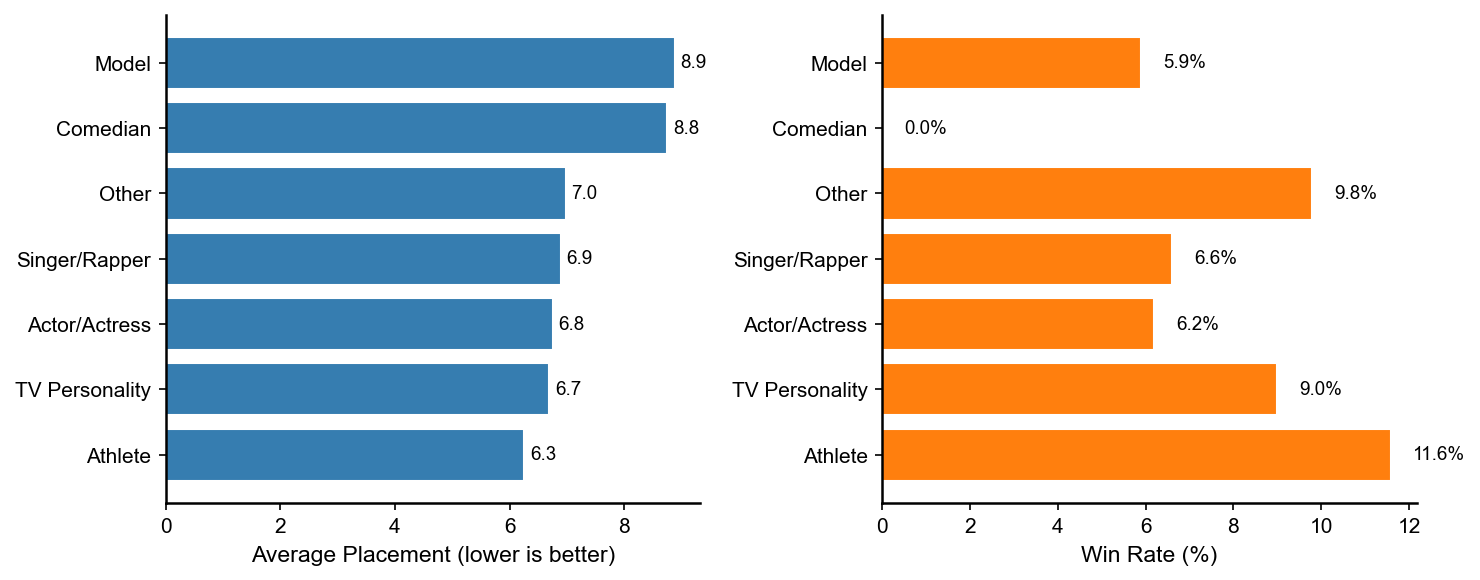

【图1数据特征 - 行业影响】
   最佳行业: Athlete (平均第6.3名)
   最差行业: Model (平均第8.9名)


In [9]:
# ============ 图1: 行业影响 ============
fig, axes = plt.subplots(1, 2, figsize=FIG_DOUBLE)

y_pos = np.arange(len(industry_stats))
bars1 = axes[0].barh(y_pos, industry_stats['avg_placement'], color=COLORS['rank_method'], edgecolor='white')
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(industry_stats.index)
axes[0].set_xlabel('Average Placement (lower is better)')
# 添加数值标记
for bar, val in zip(bars1, industry_stats['avg_placement']):
    axes[0].text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2, 
                f'{val:.1f}', va='center', fontsize=9)

bars2 = axes[1].barh(y_pos, industry_stats['win_rate'], color=COLORS['controversial'], edgecolor='white')
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(industry_stats.index)
axes[1].set_xlabel('Win Rate (%)')
# 添加数值标记
for bar, val in zip(bars2, industry_stats['win_rate']):
    axes[1].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
                f'{val:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('figures/Q3_fig1_industry_impact.pdf', format='pdf')
plt.show()

print('='*60)
print('【图1数据特征 - 行业影响】')
print(f'   最佳行业: {industry_stats.index[0]} (平均第{industry_stats.iloc[0]["avg_placement"]:.1f}名)')
print(f'   最差行业: {industry_stats.index[-1]} (平均第{industry_stats.iloc[-1]["avg_placement"]:.1f}名)')
print('='*60)

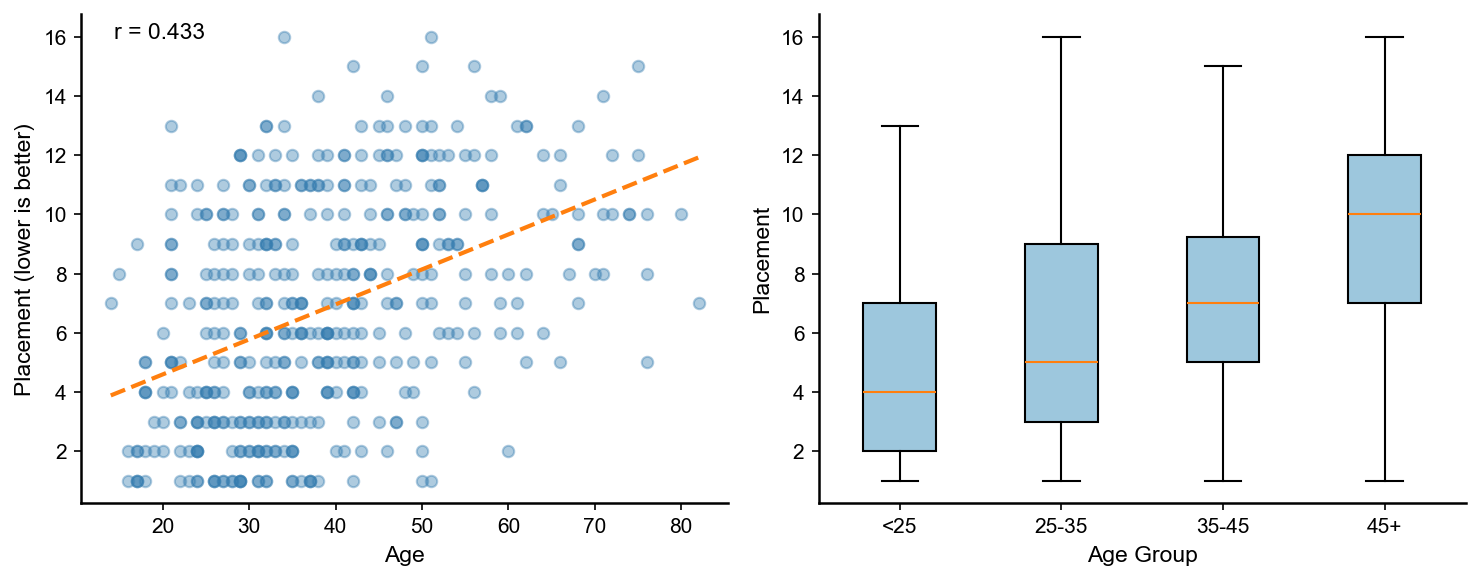

【图2数据特征 - 年龄影响】
   年龄与名次相关性: r=0.433
   <25岁平均名次: 4.8
   45+岁平均名次: 9.1


In [10]:
# ============ 图2: 年龄影响 ============
fig, axes = plt.subplots(1, 2, figsize=FIG_DOUBLE)

axes[0].scatter(df_analysis['age'], df_analysis['placement'], c=COLORS['rank_method'], alpha=0.4, s=30)
z = np.polyfit(df_analysis['age'], df_analysis['placement'], 1)
p_line = np.poly1d(z)
x_line = np.linspace(df_analysis['age'].min(), df_analysis['age'].max(), 100)
axes[0].plot(x_line, p_line(x_line), color=COLORS['controversial'], linewidth=2, linestyle='--')
axes[0].text(0.05, 0.95, f'r = {age_corr:.3f}', transform=axes[0].transAxes, fontsize=11)
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Placement (lower is better)')

age_group_labels = ['<25', '25-35', '35-45', '45+']
age_groups_data = [df_analysis[df_analysis['age_group']==k]['placement'].values for k in age_group_labels if k in df_analysis['age_group'].values]
bp = axes[1].boxplot(age_groups_data, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor(COLORS['light_blue'])
axes[1].set_xticklabels([k for k in age_group_labels if k in df_analysis['age_group'].values])
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Placement')

plt.tight_layout()
plt.savefig('figures/Q3_fig2_age_impact.pdf', format='pdf')
plt.show()

print('='*60)
print('【图2数据特征 - 年龄影响】')
print(f'   年龄与名次相关性: r={age_corr:.3f}')
print(f'   <25岁平均名次: {age_stats.loc["<25", "avg_placement"]:.1f}')
print(f'   45+岁平均名次: {age_stats.loc["45+", "avg_placement"]:.1f}')
print('='*60)

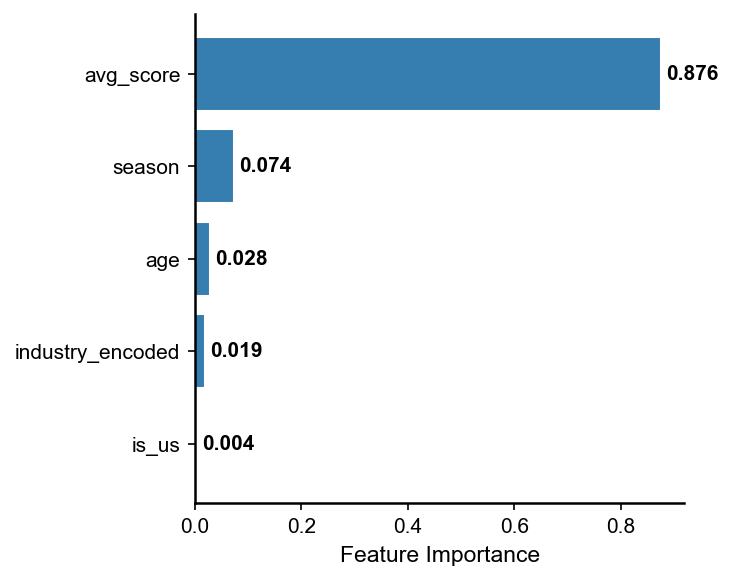

【图3数据特征 - 特征重要性】
   avg_score: 0.876
   season: 0.074
   age: 0.028
   industry_encoded: 0.019
   is_us: 0.004


In [11]:
# ============ 图3: 特征重要性 ============
fig, ax = plt.subplots(figsize=FIG_SINGLE)

y_pos = np.arange(len(feature_importance))
bars = ax.barh(y_pos, feature_importance['importance'], color=COLORS['rank_method'], edgecolor='white')
ax.set_yticks(y_pos)
ax.set_yticklabels(feature_importance['feature'])
ax.set_xlabel('Feature Importance')
ax.invert_yaxis()
# 添加数值标记
for bar, val in zip(bars, feature_importance['importance']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
           f'{val:.3f}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('figures/Q3_fig3_feature_importance.pdf', format='pdf')
plt.show()

print('='*60)
print('【图3数据特征 - 特征重要性】')
for _, row in feature_importance.iterrows():
    print(f'   {row["feature"]}: {row["importance"]:.3f}')
print('='*60)

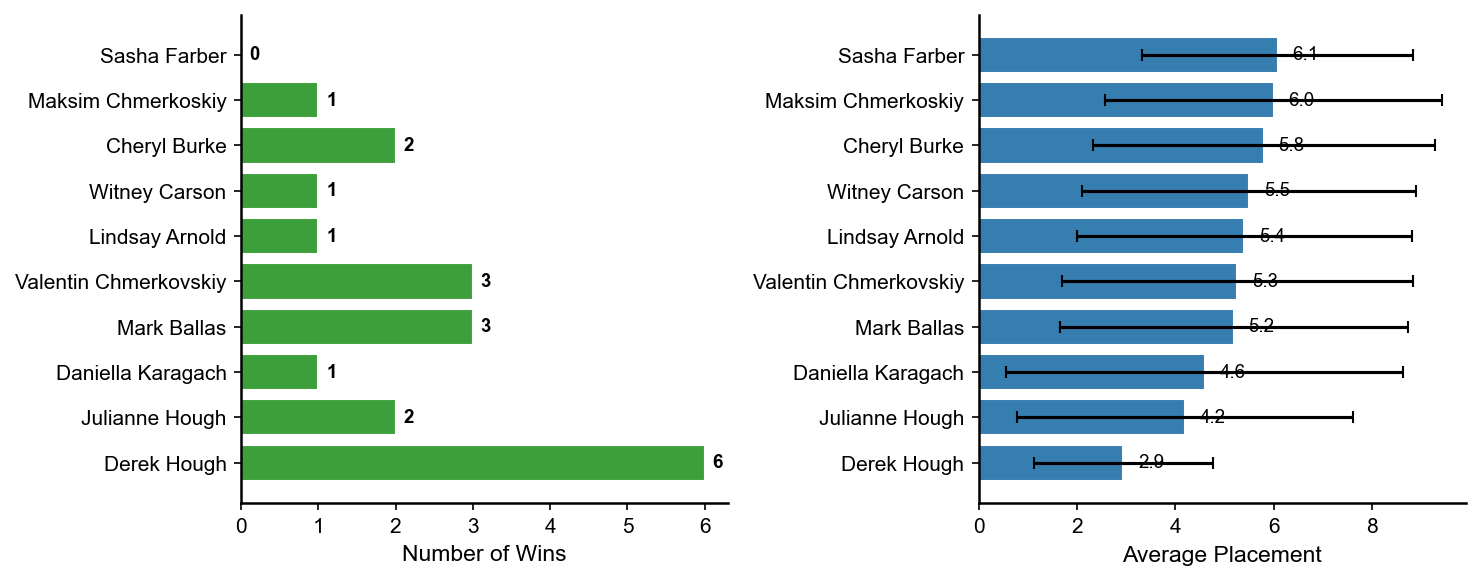

【图4数据特征 - 专业舞者】
   最佳舞伴: Derek Hough (平均第2.9名, 6冠)


In [12]:
# ============ 图4: 专业舞者影响 ============
fig, axes = plt.subplots(1, 2, figsize=FIG_DOUBLE)

top_pros = pro_stats.head(10)
y_pos = np.arange(len(top_pros))

# (a) 胜利次数
bars1 = axes[0].barh(y_pos, top_pros['wins'], color=COLORS['dwvs'], edgecolor='white')
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(top_pros.index)
axes[0].set_xlabel('Number of Wins')
axes[0].set_title('(a) Wins by Professional Partner')
# 添加数值标记
for bar, val in zip(bars1, top_pros['wins']):
    axes[0].text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2, 
                f'{int(val)}', va='center', fontsize=9, fontweight='bold')

# (b) 平均名次（带误差线）
bars2 = axes[1].barh(y_pos, top_pros['avg_placement'], xerr=top_pros['std_placement'].fillna(0), 
            color=COLORS['rank_method'], edgecolor='white', capsize=3)
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(top_pros.index)
axes[1].set_xlabel('Average Placement')
axes[1].set_title('(b) Average Placement by Professional Partner')
# 添加数值标记（稍微上移避免与误差线重叠）
for bar, val in zip(bars2, top_pros['avg_placement']):
    axes[1].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2 + 0.16, 
                f'{val:.1f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('figures/Q3_fig4_pro_dancer_impact.pdf', format='pdf')
plt.show()

print('='*60)
print('【图4数据特征 - 专业舞者】')
print(f'   最佳舞伴: {top_pros.index[0]} (平均第{top_pros.iloc[0]["avg_placement"]:.1f}名, {int(top_pros.iloc[0]["wins"])}冠)')
print('='*60)

## 第八步：结果保存与汇总

In [13]:
# 保存数据
industry_stats.to_csv('industry_analysis.csv')
pro_stats.to_csv('pro_dancer_analysis.csv')
feature_importance.to_csv('feature_importance.csv', index=False)

print('结果文件已保存')

结果文件已保存


In [14]:
# ============================================================
# 建模结果汇总（供论文引用）
# ============================================================

print("\n" + "="*70)
print("【问题三建模结果汇总】")
print("="*70)

print(f"\n📊 行业影响")
print(f"   ANOVA: F={f_stat:.3f}, p={p_val:.4f}")
print(f"   最佳行业: {industry_stats.index[0]} (平均第{industry_stats.iloc[0]['avg_placement']:.1f}名)")
print(f"   最差行业: {industry_stats.index[-1]} (平均第{industry_stats.iloc[-1]['avg_placement']:.1f}名)")

print(f"\n👤 年龄影响")
print(f"   年龄与名次相关性: r={age_corr:.3f}")
print(f"   解读: 年龄越大名次越靠后")

print(f"\n💃 专业舞者影响")
print(f"   最佳舞伴: {pro_stats.index[0]} (平均第{pro_stats.iloc[0]['avg_placement']:.1f}名, {int(pro_stats.iloc[0]['wins'])}冠)")

print(f"\n🎯 特征重要性排序")
for i, (_, row) in enumerate(feature_importance.head(3).iterrows()):
    print(f"   {i+1}. {row['feature']}: {row['importance']:.3f}")

print(f"\n📈 回归模型")
print(f"   R²: {model.rsquared:.3f}")

print(f"\n📁 生成的图片")
figures = ['Q3_fig1_industry_impact.pdf', 'Q3_fig2_age_impact.pdf', 'Q3_fig3_feature_importance.pdf', 'Q3_fig4_pro_dancer_impact.pdf']
for i, fig_name in enumerate(figures, 1):
    print(f"   图{i}: {fig_name}")

# 保存汇总
results_summary = {
    'industry_anova_f': f_stat,
    'industry_anova_p': p_val,
    'age_placement_corr': age_corr,
    'regression_r2': model.rsquared,
    'top_feature': feature_importance.iloc[0]['feature'],
    'top_feature_importance': feature_importance.iloc[0]['importance'],
}
pd.DataFrame([results_summary]).to_csv('results_summary.csv', index=False)

print("\n" + "="*70)
print("✅ 以上数值可直接用于论文撰写")
print("="*70)


【问题三建模结果汇总】

📊 行业影响
   ANOVA: F=1.784, p=0.1010
   最佳行业: Athlete (平均第6.3名)
   最差行业: Model (平均第8.9名)

👤 年龄影响
   年龄与名次相关性: r=0.433
   解读: 年龄越大名次越靠后

💃 专业舞者影响
   最佳舞伴: Derek Hough (平均第2.9名, 6冠)

🎯 特征重要性排序
   1. avg_score: 0.876
   2. season: 0.074
   3. age: 0.028

📈 回归模型
   R²: 0.648

📁 生成的图片
   图1: Q3_fig1_industry_impact.pdf
   图2: Q3_fig2_age_impact.pdf
   图3: Q3_fig3_feature_importance.pdf
   图4: Q3_fig4_pro_dancer_impact.pdf

✅ 以上数值可直接用于论文撰写
